In [1]:
import numpy as np
import matplotlib.pyplot as plt
from privacy_estimates.experiments.aml import JobList

/anaconda/envs/privacy-estimates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## (1) Let's start with AgNews

In [2]:
# first real, then synthetic - these are jobs for AgNews without canaries
jobs = JobList.from_urls([
    'https://ml.azure.com/runs/placid_wing_01zhxmz29r?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47#',
    'https://ml.azure.com/runs/good_plate_pc7ht484bf?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47#'])

In [3]:
job = jobs[0]
synthetic_job = jobs[1]

In [4]:
metrics = job.get_node('compute_utility_real').get_metrics()
metrics_synthetic = synthetic_job.get_node('compute_utility_synthetic').get_metrics()

In [5]:
metrics.keys()

dict_keys(['loss', 'learning_rate', 'epoch', 'eval_f1', 'eval_auc', 'eval_loss', 'eval_runtime', 'eval_precision', 'eval_samples_per_second', 'eval_steps_per_second', 'eval_recall', 'eval_accuracy', 'train_samples_per_second', 'train_steps_per_second', 'train_runtime', 'total_flos', 'train_loss'])

In [6]:
print(f"Real AUC: {metrics['eval_auc'][-1]}")
print(f"Synthetic AUC: {metrics_synthetic['eval_auc'][-1]}")
print(f"Real accuracy: {metrics['eval_accuracy'][-1]}")
print(f"Synthetic accuracy: {metrics_synthetic['eval_accuracy'][-1]}")

Real AUC: 0.9924603993536472
Synthetic AUC: 0.9782282894736842
Real accuracy: 0.9435526315789474
Synthetic accuracy: 0.8993421052631579


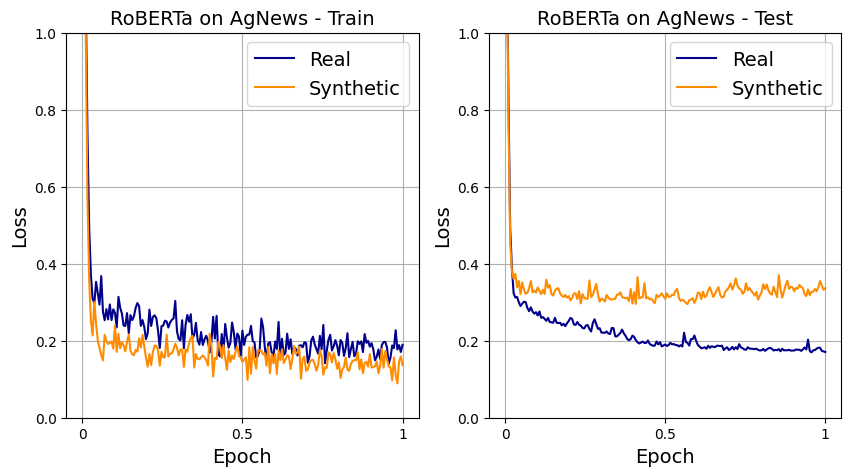

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# first do train real vs synthetic
axes[0].plot(np.linspace(0, 1, len(metrics['loss'])), metrics['loss'], color = 'darkblue', label='Real')
axes[0].plot(np.linspace(0, 1, len(metrics_synthetic['loss'])), metrics_synthetic['loss'], color = 'darkorange', label='Synthetic')
axes[0].set_xticks([0, 0.5, 1])
axes[0].set_xticklabels([0, 0.5, 1])
axes[0].legend(fontsize=14)
axes[0].grid()
axes[0].set_xlabel('Epoch', fontsize=14)
axes[0].set_ylabel('Loss', fontsize=14)
axes[0].set_ylim(0, 1.0)
axes[0].set_title('RoBERTa on AgNews - Train', fontsize=14)

# now do eval loss
axes[1].plot(np.linspace(0, 1, len(metrics['eval_loss'])), metrics['eval_loss'], color = 'darkblue', label='Real')
axes[1].plot(np.linspace(0, 1, len(metrics_synthetic['eval_loss'])), metrics_synthetic['eval_loss'], color = 'darkorange', label='Synthetic')
axes[1].set_xticks([0, 0.5, 1])
axes[1].set_xticklabels([0, 0.5, 1])
axes[1].legend(fontsize=14)
axes[1].grid()
axes[1].set_xlabel('Epoch', fontsize=14)
axes[1].set_ylabel('Loss', fontsize=14)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('RoBERTa on AgNews - Test', fontsize=14)

plt.savefig('figures/utility_agnews.pdf', dpi=300, bbox_inches='tight', pad_inches=0)

plt.show()

## (2) What about SST-2?

In [8]:
# first real, then synthetic - these are jobs for SST-2 without canaries
jobs = JobList.from_urls([
    'https://ml.azure.com/runs/teal_screw_y44k8v2k0w?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47#',
    'https://ml.azure.com/runs/brave_oregano_v2m17tb2rn?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47#'])

In [9]:
job = jobs[0]
synthetic_job = jobs[1]

metrics = job.get_node('compute_utility_real').get_metrics()
metrics_synthetic = synthetic_job.get_node('compute_utility_synthetic').get_metrics()

In [10]:
print(f"Real AUC: {metrics['eval_auc'][-1]}")
print(f"Synthetic AUC: {metrics_synthetic['eval_auc'][-1]}")
print(f"Real accuracy: {metrics['eval_accuracy'][-1]}")
print(f"Synthetic accuracy: {metrics_synthetic['eval_accuracy'][-1]}")

Real AUC: 0.9839342847520418
Synthetic AUC: 0.9676896522690915
Real accuracy: 0.9231651376146789
Synthetic accuracy: 0.9151376146788991


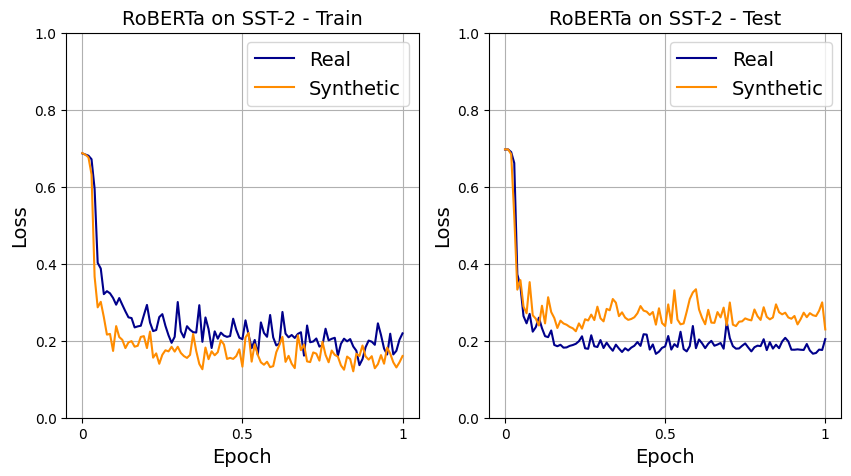

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# first do train real vs synthetic
axes[0].plot(np.linspace(0, 1, len(metrics['loss'])), metrics['loss'], color = 'darkblue', label='Real')
axes[0].plot(np.linspace(0, 1, len(metrics_synthetic['loss'])), metrics_synthetic['loss'], color = 'darkorange', label='Synthetic')
axes[0].set_xticks([0, 0.5, 1])
axes[0].set_xticklabels([0, 0.5, 1])
axes[0].legend(fontsize=14)
axes[0].grid()
axes[0].set_xlabel('Epoch', fontsize=14)
axes[0].set_ylabel('Loss', fontsize=14)
axes[0].set_ylim(0, 1.0)
axes[0].set_title('RoBERTa on SST-2 - Train', fontsize=14)

# now do eval loss
axes[1].plot(np.linspace(0, 1, len(metrics['eval_loss'])), metrics['eval_loss'], color = 'darkblue', label='Real')
axes[1].plot(np.linspace(0, 1, len(metrics_synthetic['eval_loss'])), metrics_synthetic['eval_loss'], color = 'darkorange', label='Synthetic')
axes[1].set_xticks([0, 0.5, 1])
axes[1].set_xticklabels([0, 0.5, 1])
axes[1].legend(fontsize=14)
axes[1].grid()
axes[1].set_xlabel('Epoch', fontsize=14)
axes[1].set_ylabel('Loss', fontsize=14)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('RoBERTa on SST-2 - Test', fontsize=14)

plt.savefig('figures/utility_sst2.pdf', dpi=300, bbox_inches='tight', pad_inches=0)

plt.show()

## (3) Let's also look at this when we have included canaries

In [12]:
canary_to_url = {
    'sst2_in_canary': 'https://ml.azure.com/runs/hungry_holiday_qczmtvhk9z?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47', 
    'sst2_syntheticcanary_uniformlabel': 'https://ml.azure.com/runs/purple_basil_ym4kcffrdq?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
    'sst2_syntheticcanary_canarylabel': 'https://ml.azure.com/runs/sharp_farm_f0t24t04nx?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
    'agnews_in_canary': 'https://ml.azure.com/runs/neat_circle_b73nft4qj2?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
    'agnews_syntheticcanary_uniformlabel': 'https://ml.azure.com/runs/dynamic_lamp_9dth0rjpnj?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
    'agnews_syntheticcanary_canarylabel': 'https://ml.azure.com/runs/honest_bee_3082g51276?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47'
}

In [13]:
for canary_method in canary_to_url.keys():
    print('Canary method: ', canary_method)
    url = canary_to_url[canary_method]
    if url != 'xx':
        jobs = JobList.from_urls([url])
        job = jobs[0]
        metrics = job.get_node('compute_utility_synthetic').get_metrics()
        print(f"AUC: {metrics['eval_auc'][-1]}")
        print(f"accuracy: {metrics['eval_accuracy'][-1]}")
    else:
        print('No data available')
    print('---')


Canary method:  sst2_in_canary
AUC: 0.9715626841795066
accuracy: 0.9185779816513762
---
Canary method:  sst2_syntheticcanary_uniformlabel
AUC: 0.9590384777300663
accuracy: 0.893348623853211
---
Canary method:  sst2_syntheticcanary_canarylabel
AUC: 0.9618958912183212
accuracy: 0.8990825688073395
---
Canary method:  agnews_in_canary
AUC: 0.977587176823638
accuracy: 0.8984210526315789
---
Canary method:  agnews_syntheticcanary_uniformlabel
AUC: 0.9774332640812559
accuracy: 0.8855263157894737
---
Canary method:  agnews_syntheticcanary_canarylabel
AUC: 0.979646179593721
accuracy: 0.9013157894736842
---
